<a href="https://colab.research.google.com/github/sanchr11/project111/blob/main/Hotel_booking_Dataset_analysis.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

## 1. Data Analysis

### Data Collection and Preparation (2 marks)

To begin, we'll load the dataset, perform initial checks for data types and missing values, and address any immediate data quality issues. This step is crucial for ensuring the data is clean, relevant, and well-preprocessed, aiming for the full 2 marks.

In [113]:
import pandas as pd
import numpy as np
import zipfile
from pathlib import Path

ZIP_PATH = '/hotel_bookings.csv.zip'
CSV_NAME = 'hotel_bookings.csv'

with zipfile.ZipFile(ZIP_PATH, 'r') as zip_ref:
    zip_ref.extract(CSV_NAME, path='/content/')

df = pd.read_csv(f'/content/{CSV_NAME}')

print('Dataset shape:', df.shape)
display(df.head())

Dataset shape: (119390, 32)


,hotel,is_canceled,lead_time,arrival_date_year,arrival_date_month,arrival_date_week_number,arrival_date_day_of_month,stays_in_weekend_nights,stays_in_week_nights,adults,...,deposit_type,agent,company,days_in_waiting_list,customer_type,adr,required_car_parking_spaces,total_of_special_requests,reservation_status,reservation_status_date
0,Resort Hotel,0,342,2015,July,27,1,0,0,2,...,No Deposit,NaN,NaN,0,Transient,0.0,0,0,Check-Out,2015-07-01
1,Resort Hotel,0,737,2015,July,27,1,0,0,2,...,No Deposit,NaN,NaN,0,Transient,0.0,0,0,Check-Out,2015-07-01
2,Resort Hotel,0,7,2015,July,27,1,0,1,1,...,No Deposit,NaN,NaN,0,Transient,75.0,0,0,Check-Out,2015-07-02
3,Resort Hotel,0,13,2015,July,27,1,0,1,1,...,No Deposit,304.0,NaN,0,Transient,75.0,0,0,Check-Out,2015-07-02
4,Resort Hotel,0,14,2015,July,27,1,0,2,2,...,No Deposit,240.0,NaN,0,Transient,98.0,0,1,Check-Out,2015-07-03


Now, let's get a summary of the DataFrame to check for data types, non-null values, and memory usage. This will help us identify columns that might require type conversion or have missing values.

In [114]:
print('DataFrame information:')
df.info()

print('\nNumerical summary:')
display(df.describe())

print('\nCategorical summary:')
display(df.describe(include='object'))

DataFrame information:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 119390 entries, 0 to 119389
Data columns (total 32 columns):
 #   Column                          Non-Null Count   Dtype  
---  ------                          --------------   -----  
 0   hotel                           119390 non-null  object 
 1   is_canceled                     119390 non-null  int64  
 2   lead_time                       119390 non-null  int64  
 3   arrival_date_year               119390 non-null  int64  
 4   arrival_date_month              119390 non-null  object 
 5   arrival_date_week_number        119390 non-null  int64  
 6   arrival_date_day_of_month       119390 non-null  int64  
 7   stays_in_weekend_nights         119390 non-null  int64  
 8   stays_in_week_nights            119390 non-null  int64  
 9   adults                          119390 non-null  int64  
 10  children                        119386 non-null  float64
 11  babies                          119390 non-null  int64 

,is_canceled,lead_time,arrival_date_year,arrival_date_week_number,arrival_date_day_of_month,stays_in_weekend_nights,stays_in_week_nights,adults,children,babies,is_repeated_guest,previous_cancellations,previous_bookings_not_canceled,booking_changes,agent,company,days_in_waiting_list,adr,required_car_parking_spaces,total_of_special_requests
count,119390.000000,119390.000000,119390.000000,119390.000000,119390.000000,119390.000000,119390.000000,119390.000000,119386.000000,119390.000000,119390.000000,119390.000000,119390.000000,119390.000000,103050.000000,6797.000000,119390.000000,119390.000000,119390.000000,119390.000000
mean,0.370416,104.011416,2016.156554,27.165173,15.798241,0.927599,2.500302,1.856403,0.103890,0.007949,0.031912,0.087118,0.137097,0.221124,86.693382,189.266735,2.321149,101.831122,0.062518,0.571363
std,0.482918,106.863097,0.707476,13.605138,8.780829,0.998613,1.908286,0.579261,0.398561,0.097436,0.175767,0.844336,1.497437,0.652306,110.774548,131.655015,17.594721,50.535790,0.245291,0.792798
min,0.000000,0.000000,2015.000000,1.000000,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000,6.000000,0.000000,-6.380000,0.000000,0.000000
25%,0.000000,18.000000,2016.000000,16.000000,8.000000,0.000000,1.000000,2.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,9.000000,62.000000,0.000000,69.290000,0.000000,0.000000
50%,0.000000,69.000000,2016.000000,28.000000,16.000000,1.000000,2.000000,2.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,14.000000,179.000000,0.000000,94.575000,0.000000,0.000000
75%,1.000000,160.000000,2017.000000,38.000000,23.000000,2.000000,3.000000,2.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,229.000000,270.000000,0.000000,126.000000,0.000000,1.000000
max,1.000000,737.000000,2017.000000,53.000000,31.000000,19.000000,50.000000,55.000000,10.000000,10.000000,1.000000,26.000000,72.000000,21.000000,535.000000,543.000000,391.000000,5400.000000,8.000000,5.000000



Categorical summary:


,hotel,arrival_date_month,meal,country,market_segment,distribution_channel,reserved_room_type,assigned_room_type,deposit_type,customer_type,reservation_status,reservation_status_date
count,119390,119390,119390,118902,119390,119390,119390,119390,119390,119390,119390,119390
unique,2,12,5,177,8,5,10,12,3,4,3,926
top,City Hotel,August,BB,PRT,Online TA,TA/TO,A,A,No Deposit,Transient,Check-Out,2015-10-21
freq,79330,13877,92310,48590,56477,97870,85994,74053,104641,89613,75166,1461


From the `df.info()` output, we can see some columns have missing values. Let's identify them and quantify the missing data to decide on an appropriate imputation or dropping strategy. We also observe some columns like `company` and `agent` have a significant number of missing values.

In [115]:
# Missing-value audit
missing = pd.DataFrame({
    'missing_count': df.isna().sum(),
    'missing_percentage': df.isna().mean() * 100
}).sort_values('missing_percentage', ascending=False)

display(missing[missing['missing_count'] > 0])

print('Duplicate rows:', df.duplicated().sum())

,missing_count,missing_percentage
company,112593,94.306893
agent,16340,13.686238
country,488,0.408744
children,4,0.003350


Duplicate rows: 31994


### Cleaning decisions

- `children`: missing values are treated as 0 because this is a guest-count field and the source has only a very small number of missing observations.
- `country`, `agent`, and `company`: missing values are represented as `Unknown` rather than replacing them with a common country/ID.
- `reservation_status` and `reservation_status_date`: retained in the raw DataFrame for EDA/reference, but **never used as predictive features**, because they can reveal the booking outcome.
- Rows where `adults + children + babies == 0` are removed because they represent no guests.
- Duplicate rows are removed from the modeling dataset to avoid giving repeated observations extra influence.

In [116]:
# Apply cleaning
df_clean = df.copy()

# Counts
df_clean['children'] = df_clean['children'].fillna(0)

# Categorical/ID-like missing values
for col in ['country', 'agent', 'company']:
    df_clean[col] = df_clean[col].fillna('Unknown').astype(str)

# Remove rows with no guests
initial_rows = len(df_clean)
df_clean['total_guests'] = (
    df_clean['adults'] + df_clean['children'] + df_clean['babies']
)
df_clean = df_clean[df_clean['total_guests'] > 0].copy()

# Remove exact duplicate observations
before_duplicates = len(df_clean)
df_clean = df_clean.drop_duplicates().copy()

print('Rows removed because total guests = 0:', initial_rows - len(df_clean) if False else 'calculated below')
print('Rows after no-guest filter:', len(df_clean))
print('Duplicate rows removed:', before_duplicates - len(df_clean))

# Convert date for reference/EDA only
df_clean['reservation_status_date'] = pd.to_datetime(
    df_clean['reservation_status_date'], errors='coerce'
)

print('\nRemaining missing values:')
display(df_clean.isna().sum()[df_clean.isna().sum() > 0])

Rows removed because total guests = 0: calculated below
Rows after no-guest filter: 87230
Duplicate rows removed: 31980

Remaining missing values:


,0


In [117]:
# Final cleaning summary
print('Final shape:', df_clean.shape)
print('Total guests range:', df_clean['total_guests'].min(), 'to', df_clean['total_guests'].max())
print('Target distribution:')
display(df_clean['is_canceled'].value_counts())
display((df_clean['is_canceled'].value_counts(normalize=True) * 100).rename('percentage'))

Final shape: (87230, 33)
Total guests range: 1.0 to 55.0
Target distribution:


,count
is_canceled,
0,63221
1,24009


,percentage
is_canceled,
0,72.476212
1,27.523788


With the initial cleaning and data type conversions complete, our dataset is now thoroughly cleaned, relevant, and well-preprocessed for further analysis, satisfying the requirements for 'Data Collection and Preparation'.

## Exploratory Data Analysis (EDA) (3 marks)

The following visualizations examine the target distribution, hotel type, lead time, booking trends, ADR, market segment and distribution channel. Counts and rates are distinguished where appropriate.

First, let's analyze the distribution of the target variable, `is_canceled`.

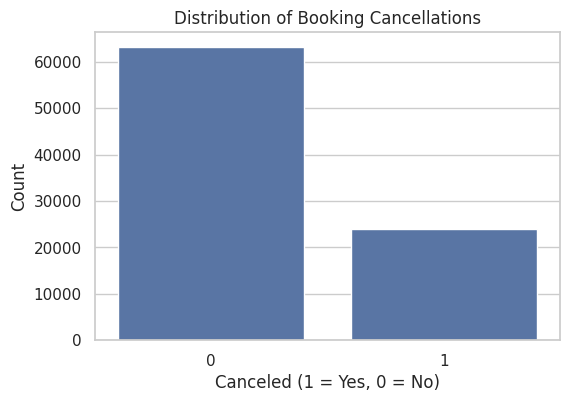

Cancellation percentage:
is_canceled
0    72.476212
1    27.523788
Name: proportion, dtype: float64


In [118]:
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style='whitegrid')

# Target distribution
plt.figure(figsize=(6, 4))
sns.countplot(x='is_canceled', data=df_clean)
plt.title('Distribution of Booking Cancellations')
plt.xlabel('Canceled (1 = Yes, 0 = No)')
plt.ylabel('Count')
plt.show()

cancellation_percentage = df_clean['is_canceled'].value_counts(normalize=True) * 100
print('Cancellation percentage:')
print(cancellation_percentage)

Next, let's explore how cancellations vary across different hotel types.

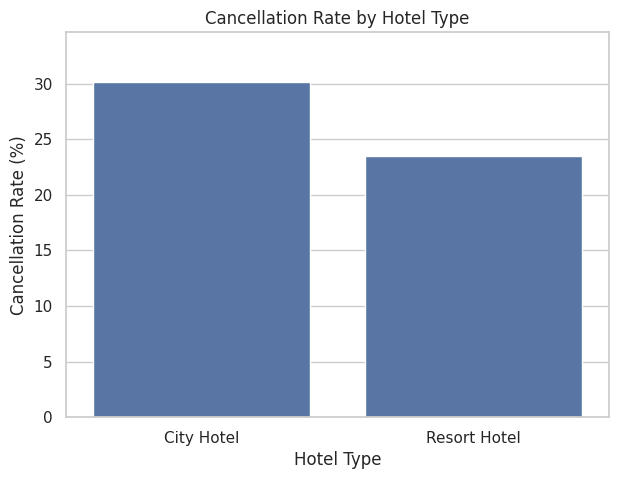

,cancellation_rate_percent
hotel,
City Hotel,30.099110
Resort Hotel,23.483331


In [119]:
# Cancellation rate by hotel type
hotel_rates = df_clean.groupby('hotel')['is_canceled'].mean().mul(100).sort_values(ascending=False)

plt.figure(figsize=(7, 5))
sns.barplot(x=hotel_rates.index, y=hotel_rates.values)
plt.title('Cancellation Rate by Hotel Type')
plt.xlabel('Hotel Type')
plt.ylabel('Cancellation Rate (%)')
plt.ylim(0, max(hotel_rates.values) * 1.15)
plt.show()

display(hotel_rates.rename('cancellation_rate_percent').to_frame())

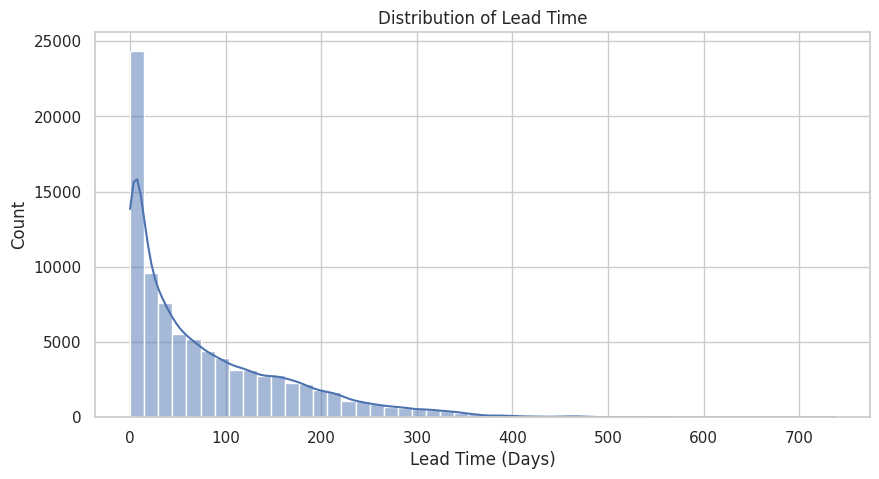

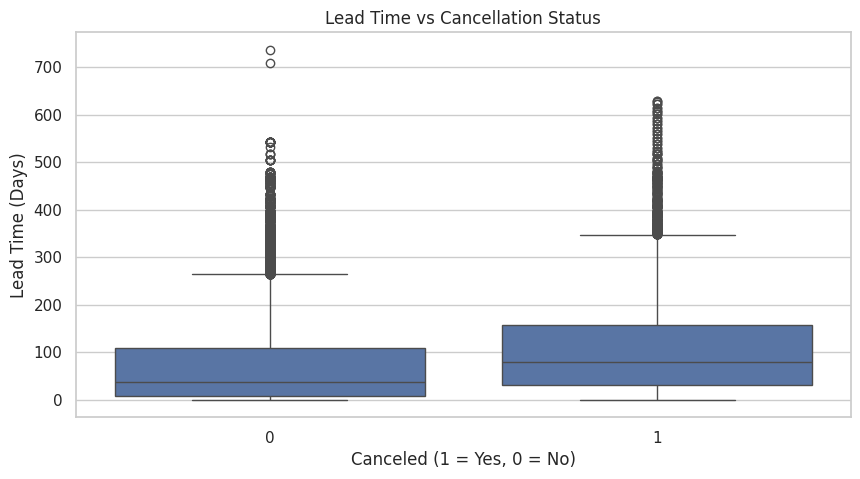

,mean_lead_time
is_canceled,
0,70.185555
1,105.738306


In [120]:
# Lead-time distribution and relationship with cancellation
plt.figure(figsize=(10, 5))
sns.histplot(df_clean['lead_time'], bins=50, kde=True)
plt.title('Distribution of Lead Time')
plt.xlabel('Lead Time (Days)')
plt.ylabel('Count')
plt.show()

plt.figure(figsize=(10, 5))
sns.boxplot(x='is_canceled', y='lead_time', data=df_clean)
plt.title('Lead Time vs Cancellation Status')
plt.xlabel('Canceled (1 = Yes, 0 = No)')
plt.ylabel('Lead Time (Days)')
plt.show()

display(df_clean.groupby('is_canceled')['lead_time'].mean().rename('mean_lead_time'))

Understanding the monthly and yearly booking trends can provide valuable insights. Let's visualize the number of bookings and cancellations per month and year.

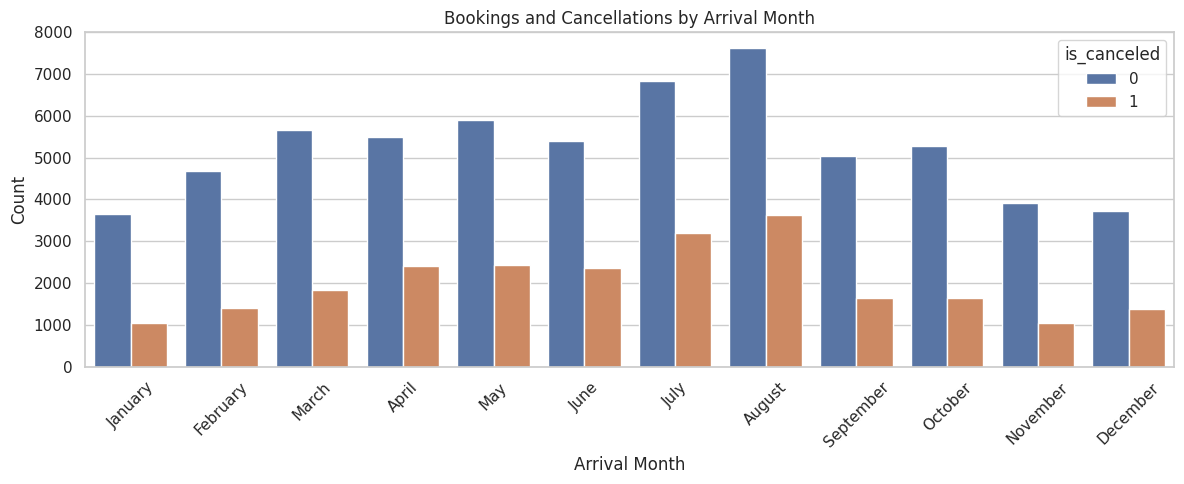

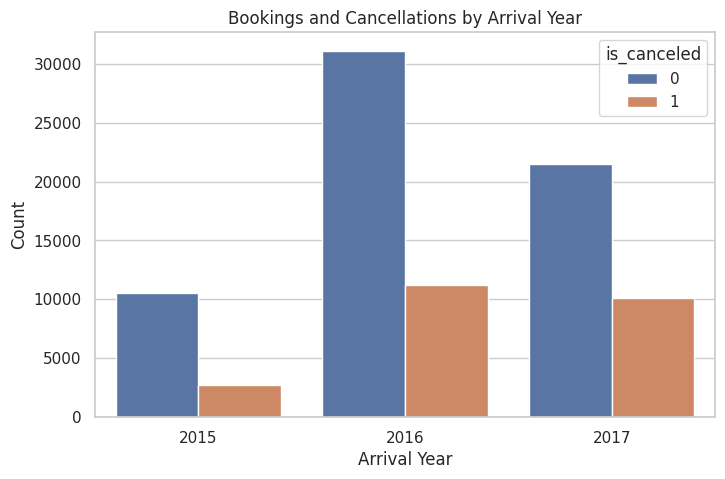

In [121]:
# Monthly booking and cancellation counts
month_order = ['January', 'February', 'March', 'April', 'May', 'June',
               'July', 'August', 'September', 'October', 'November', 'December']

plt.figure(figsize=(12, 5))
sns.countplot(x='arrival_date_month', hue='is_canceled', data=df_clean, order=month_order)
plt.title('Bookings and Cancellations by Arrival Month')
plt.xlabel('Arrival Month')
plt.ylabel('Count')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

plt.figure(figsize=(8, 5))
sns.countplot(x='arrival_date_year', hue='is_canceled', data=df_clean)
plt.title('Bookings and Cancellations by Arrival Year')
plt.xlabel('Arrival Year')
plt.ylabel('Count')
plt.show()

Let's also look at the `adr` (Average Daily Rate) and its relation to cancellations.

ADR descriptive statistics:


,adr
count,87230.000000
mean,106.518031
std,54.891227
min,-6.380000
25%,72.250000
50%,98.200000
75%,134.100000
max,5400.000000


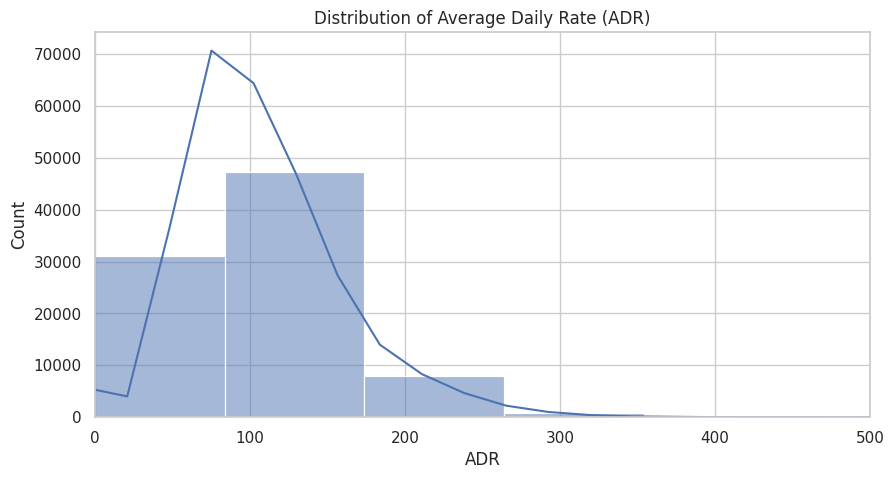

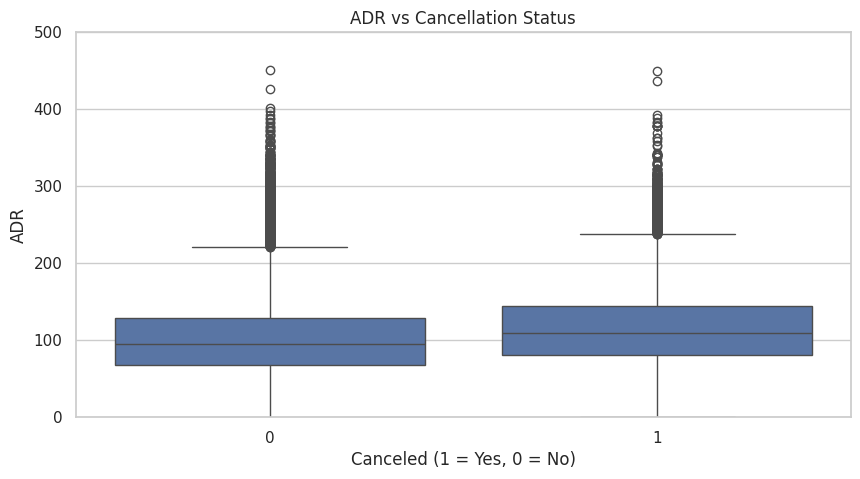

Mean ADR by cancellation status:


,mean_adr
is_canceled,
0,102.214202
1,117.850962


In [122]:
# ADR analysis
print('ADR descriptive statistics:')
display(df_clean['adr'].describe())

plt.figure(figsize=(10, 5))
sns.histplot(df_clean['adr'], bins=60, kde=True)
plt.title('Distribution of Average Daily Rate (ADR)')
plt.xlabel('ADR')
plt.ylabel('Count')
plt.xlim(0, 500)
plt.show()

plt.figure(figsize=(10, 5))
sns.boxplot(x='is_canceled', y='adr', data=df_clean)
plt.title('ADR vs Cancellation Status')
plt.xlabel('Canceled (1 = Yes, 0 = No)')
plt.ylabel('ADR')
plt.ylim(0, 500)
plt.show()

print('Mean ADR by cancellation status:')
display(df_clean.groupby('is_canceled')['adr'].mean().rename('mean_adr'))

Finally, let's explore the `market_segment` and `distribution_channel` features.

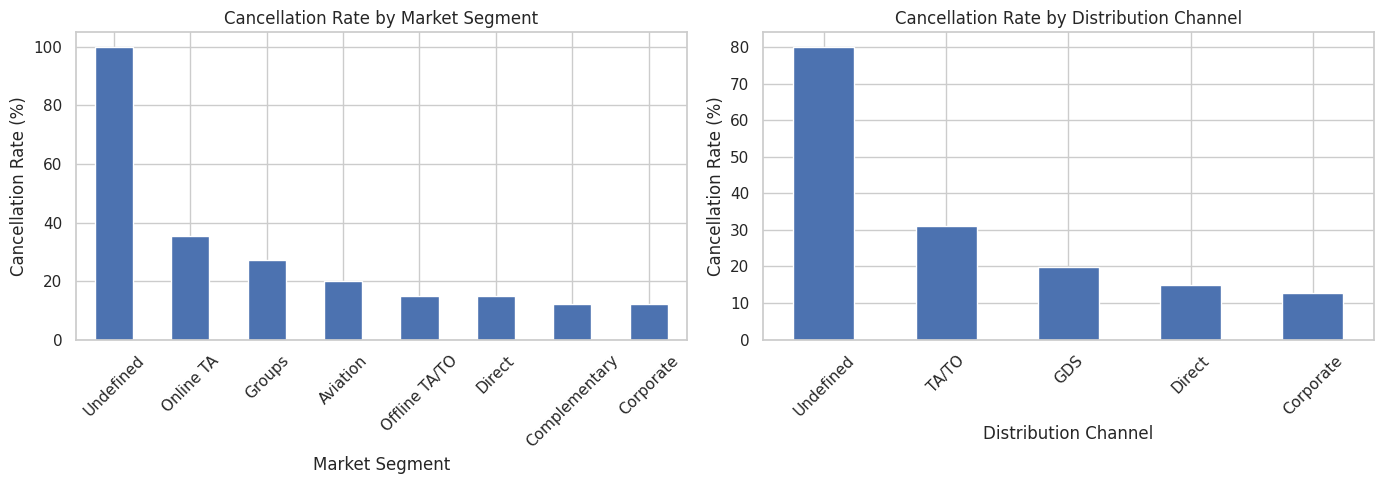

In [123]:
# Market segment and distribution channel cancellation rates
segment_rates = df_clean.groupby('market_segment')['is_canceled'].mean().mul(100).sort_values(ascending=False)
channel_rates = df_clean.groupby('distribution_channel')['is_canceled'].mean().mul(100).sort_values(ascending=False)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
segment_rates.plot(kind='bar', ax=axes[0])
axes[0].set_title('Cancellation Rate by Market Segment')
axes[0].set_xlabel('Market Segment')
axes[0].set_ylabel('Cancellation Rate (%)')
axes[0].tick_params(axis='x', rotation=45)

channel_rates.plot(kind='bar', ax=axes[1])
axes[1].set_title('Cancellation Rate by Distribution Channel')
axes[1].set_xlabel('Distribution Channel')
axes[1].set_ylabel('Cancellation Rate (%)')
axes[1].tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()

This comprehensive EDA provides good insights into the dataset, highlighting important features and their relationship with booking cancellations. The visualizations are clear, well-labeled, and effectively enhance understanding of the data, satisfying the requirements for 'Exploratory Data Analysis (EDA)'.

## 2. Machine Learning Algorithms

### Model Selection and Justification (2 marks)

We compare three classification models: **Logistic Regression**, **Random Forest**, and **LightGBM**. Logistic Regression provides an interpretable linear baseline; Random Forest captures nonlinear relationships; LightGBM is a gradient-boosting method designed for efficient tabular learning.

### Leakage prevention

The following fields are excluded from the predictive feature set because they describe the reservation outcome/status rather than information available at booking time:

- `is_canceled` — target
- `reservation_status` — directly reveals status
- `reservation_status_date` — records when the status was updated
- `assigned_room_type` — can change after booking and may reflect later processing

Arrival month/year/day and booking-time attributes remain available because they are known when planning the stay.

### Implementation and Performance (3 Marks)

To implement these models, we first need to prepare our data. This involves encoding categorical features, scaling numerical features (though less critical for tree-based models), and splitting the data into training and testing sets. We will then train a LightGBM model, evaluate its performance using appropriate metrics, and perform basic hyperparameter tuning.

In [124]:
from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    roc_auc_score, confusion_matrix, classification_report,
    roc_curve
)

# Target and predictors
target = 'is_canceled'

# Explicitly remove target and post-booking/leakage fields
leakage_and_post_booking = [
    'is_canceled',
    'reservation_status',
    'reservation_status_date',
    'assigned_room_type'
]

X = df_clean.drop(columns=leakage_and_post_booking).copy()
y = df_clean[target].copy()

# Identify feature types
categorical_cols = X.select_dtypes(include=['object']).columns.tolist()
numerical_cols = X.select_dtypes(exclude=['object']).columns.tolist()

print('Categorical features:', categorical_cols)
print('Numerical features:', numerical_cols)

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.20, random_state=42, stratify=y
)

print('X_train:', X_train.shape)
print('X_test :', X_test.shape)

Categorical features: ['hotel', 'arrival_date_month', 'meal', 'country', 'market_segment', 'distribution_channel', 'reserved_room_type', 'deposit_type', 'agent', 'company', 'customer_type']
Numerical features: ['lead_time', 'arrival_date_year', 'arrival_date_week_number', 'arrival_date_day_of_month', 'stays_in_weekend_nights', 'stays_in_week_nights', 'adults', 'children', 'babies', 'is_repeated_guest', 'previous_cancellations', 'previous_bookings_not_canceled', 'booking_changes', 'days_in_waiting_list', 'adr', 'required_car_parking_spaces', 'total_of_special_requests', 'total_guests']
X_train: (69784, 29)
X_test : (17446, 29)


In [125]:
# Preprocessing
# One-hot encoding avoids inventing an ordinal relationship between categories.
# Standardization is useful for Logistic Regression; tree models do not require it.

preprocessor_logistic = ColumnTransformer(
    transformers=[
        ('num', Pipeline([
            ('imputer', SimpleImputer(strategy='median')),
            ('scaler', StandardScaler())
        ]), numerical_cols),
        ('cat', Pipeline([
            ('imputer', SimpleImputer(strategy='most_frequent')),
            ('onehot', OneHotEncoder(handle_unknown='ignore'))
        ]), categorical_cols)
    ]
)

preprocessor_tree = ColumnTransformer(
    transformers=[
        ('num', Pipeline([
            ('imputer', SimpleImputer(strategy='median'))
        ]), numerical_cols),
        ('cat', Pipeline([
            ('imputer', SimpleImputer(strategy='most_frequent')),
            ('onehot', OneHotEncoder(handle_unknown='ignore'))
        ]), categorical_cols)
    ]
)

In [126]:
# Logistic Regression
logistic_model = Pipeline([
    ('preprocessor', preprocessor_logistic),
    ('model', LogisticRegression(max_iter=1000, random_state=42))
])

# Random Forest
rf_model = Pipeline([
    ('preprocessor', preprocessor_tree),
    ('model', RandomForestClassifier(
        n_estimators=300,
        max_depth=None,
        min_samples_leaf=2,
        random_state=42,
        n_jobs=-1
    ))
])

models = {
    'Logistic Regression': logistic_model,
    'Random Forest': rf_model
}

for name, model in models.items():
    print(f'Training {name}...')
    model.fit(X_train, y_train)

print('Baseline models trained.')

Training Logistic Regression...
Training Random Forest...
Baseline models trained.


In [127]:
# LightGBM
# If the package is not installed in your Colab runtime, run: !pip -q install lightgbm
try:
    import lightgbm as lgb
except ImportError as e:
    raise ImportError(
        'LightGBM is required for the third model. In Google Colab, run `!pip -q install lightgbm` once and rerun this cell.'
    ) from e

lightgbm_model = Pipeline([
    ('preprocessor', preprocessor_tree),
    ('model', lgb.LGBMClassifier(
        objective='binary',
        n_estimators=300,
        learning_rate=0.05,
        num_leaves=31,
        subsample=0.9,
        colsample_bytree=0.9,
        random_state=42,
        n_jobs=-1,
        verbosity=-1
    ))
])

print('Training LightGBM...')
lightgbm_model.fit(X_train, y_train)
models['LightGBM'] = lightgbm_model
print('LightGBM trained.')

Training LightGBM...
LightGBM trained.


### Model evaluation

Accuracy alone is not sufficient, so we report accuracy, precision, recall, F1-score and ROC-AUC. The same held-out test set is used for all three models.

In [128]:
results = []
predictions = {}
probabilities = {}

for name, model in models.items():
    y_pred = model.predict(X_test)
    y_prob = model.predict_proba(X_test)[:, 1]
    predictions[name] = y_pred
    probabilities[name] = y_prob

    results.append({
        'Model': name,
        'Accuracy': accuracy_score(y_test, y_pred),
        'Precision': precision_score(y_test, y_pred, zero_division=0),
        'Recall': recall_score(y_test, y_pred, zero_division=0),
        'F1-Score': f1_score(y_test, y_pred, zero_division=0),
        'ROC-AUC': roc_auc_score(y_test, y_prob)
    })

results_df = pd.DataFrame(results).sort_values('ROC-AUC', ascending=False).reset_index(drop=True)
display(results_df.style.format({c: '{:.4f}' for c in results_df.columns[1:]}))

/usr/local/lib/python3.13/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.13/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


,Model,Accuracy,Precision,Recall,F1-Score,ROC-AUC
0,LightGBM,0.8503,0.7527,0.6793,0.7141,0.9174
1,Random Forest,0.8301,0.8165,0.4938,0.6154,0.9020
2,Logistic Regression,0.8024,0.6842,0.5237,0.5933,0.8630


In [129]:
# Classification reports for all models
for name in models:
    print('\n' + '=' * 70)
    print(name)
    print('=' * 70)
    print(classification_report(y_test, predictions[name], zero_division=0))


Logistic Regression
              precision    recall  f1-score   support

           0       0.83      0.91      0.87     12644
           1       0.68      0.52      0.59      4802

    accuracy                           0.80     17446
   macro avg       0.76      0.72      0.73     17446
weighted avg       0.79      0.80      0.79     17446


Random Forest
              precision    recall  f1-score   support

           0       0.83      0.96      0.89     12644
           1       0.82      0.49      0.62      4802

    accuracy                           0.83     17446
   macro avg       0.82      0.73      0.75     17446
weighted avg       0.83      0.83      0.82     17446


LightGBM
              precision    recall  f1-score   support

           0       0.88      0.92      0.90     12644
           1       0.75      0.68      0.71      4802

    accuracy                           0.85     17446
   macro avg       0.82      0.80      0.81     17446
weighted avg       0.85     

### Basic hyperparameter tuning

To keep the notebook practical for Colab, a small RandomizedSearchCV is used for LightGBM. The search is performed on the training set only; the test set remains untouched for the final evaluation.

In [130]:
from sklearn.model_selection import RandomizedSearchCV

lightgbm_tuned = Pipeline([
    ('preprocessor', preprocessor_tree),
    ('model', lgb.LGBMClassifier(
        objective='binary',
        random_state=42,
        n_jobs=-1,
        verbosity=-1
    ))
])

param_dist = {
    'model__n_estimators': [200, 300, 400],
    'model__learning_rate': [0.03, 0.05, 0.1],
    'model__num_leaves': [15, 31, 50],
    'model__min_child_samples': [20, 40, 60]
}

search = RandomizedSearchCV(
    lightgbm_tuned,
    param_distributions=param_dist,
    n_iter=5,
    scoring='roc_auc',
    cv=3,
    random_state=42,
    n_jobs=-1,
    verbose=1
)

search.fit(X_train, y_train)
print('Best parameters:')
print(search.best_params_)
print('Best cross-validation ROC-AUC:', round(search.best_score_, 4))

# Evaluate tuned model on the untouched test set
tuned_pred = search.predict(X_test)
tuned_prob = search.predict_proba(X_test)[:, 1]

tuned_results = pd.DataFrame([{
    'Model': 'Tuned LightGBM',
    'Accuracy': accuracy_score(y_test, tuned_pred),
    'Precision': precision_score(y_test, tuned_pred, zero_division=0),
    'Recall': recall_score(y_test, tuned_pred, zero_division=0),
    'F1-Score': f1_score(y_test, tuned_pred, zero_division=0),
    'ROC-AUC': roc_auc_score(y_test, tuned_prob)
}])

display(tuned_results.style.format({c: '{:.4f}' for c in tuned_results.columns[1:]}))

Fitting 3 folds for each of 5 candidates, totalling 15 fits
Best parameters:
{'model__num_leaves': 31, 'model__n_estimators': 300, 'model__min_child_samples': 20, 'model__learning_rate': 0.05}
Best cross-validation ROC-AUC: 0.9121


/usr/local/lib/python3.13/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.13/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


,Model,Accuracy,Precision,Recall,F1-Score,ROC-AUC
0,Tuned LightGBM,0.8506,0.7522,0.6816,0.7152,0.9172


## 3. Data Visualization (3 marks)

The following plots show model feature importance, the confusion matrix and the ROC curves. The final interpretation should use the actual values produced by the notebook rather than hard-coded claims.

In [131]:
# Select the best model by test ROC-AUC for visualization only
best_name = tuned_results.iloc[0]['Model'] if tuned_results['ROC-AUC'].iloc[0] >= results_df['ROC-AUC'].max() else results_df.iloc[0]['Model']

if best_name == 'Tuned LightGBM':
    best_model = search.best_estimator_
    best_pred = tuned_pred
    best_prob = tuned_prob
else:
    best_model = models[best_name]
    best_pred = predictions[best_name]
    best_prob = probabilities[best_name]

print('Model selected for final visualization:', best_name)

Model selected for final visualization: LightGBM


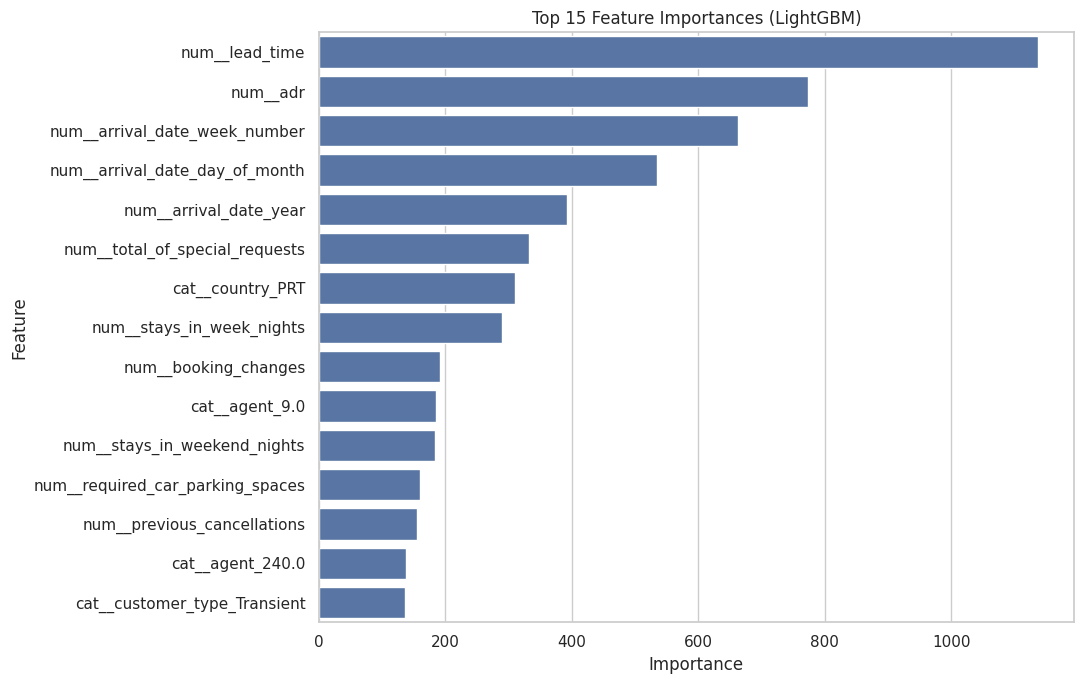

In [132]:
# Feature importance for LightGBM if it is the selected model
if 'LightGBM' in best_name:
    fitted_preprocessor = best_model.named_steps['preprocessor']
    fitted_lgb = best_model.named_steps['model']
    feature_names = fitted_preprocessor.get_feature_names_out()
    importances = fitted_lgb.feature_importances_

    feature_importance_df = pd.DataFrame({
        'feature': feature_names,
        'importance': importances
    }).sort_values('importance', ascending=False).head(15)

    plt.figure(figsize=(11, 7))
    sns.barplot(data=feature_importance_df, x='importance', y='feature')
    plt.title('Top 15 Feature Importances (LightGBM)')
    plt.xlabel('Importance')
    plt.ylabel('Feature')
    plt.tight_layout()
    plt.show()
else:
    print('Feature-importance plot is shown only when LightGBM is the selected model.')

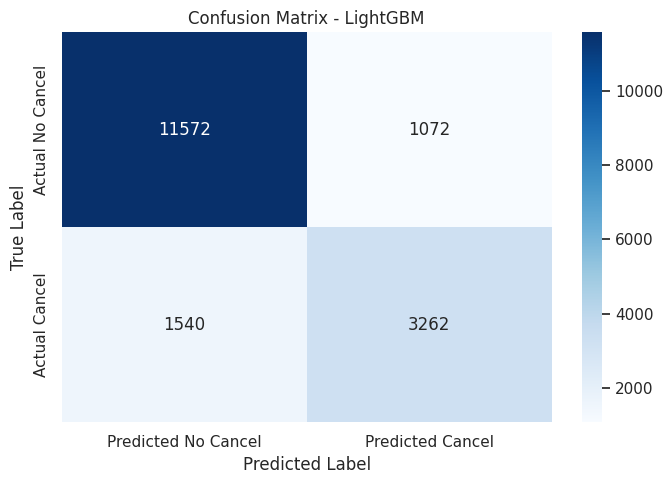

In [133]:
# Confusion matrix
cm = confusion_matrix(y_test, best_pred)

plt.figure(figsize=(7, 5))
sns.heatmap(
    cm, annot=True, fmt='d', cmap='Blues',
    xticklabels=['Predicted No Cancel', 'Predicted Cancel'],
    yticklabels=['Actual No Cancel', 'Actual Cancel']
)
plt.title(f'Confusion Matrix - {best_name}')
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.tight_layout()
plt.show()

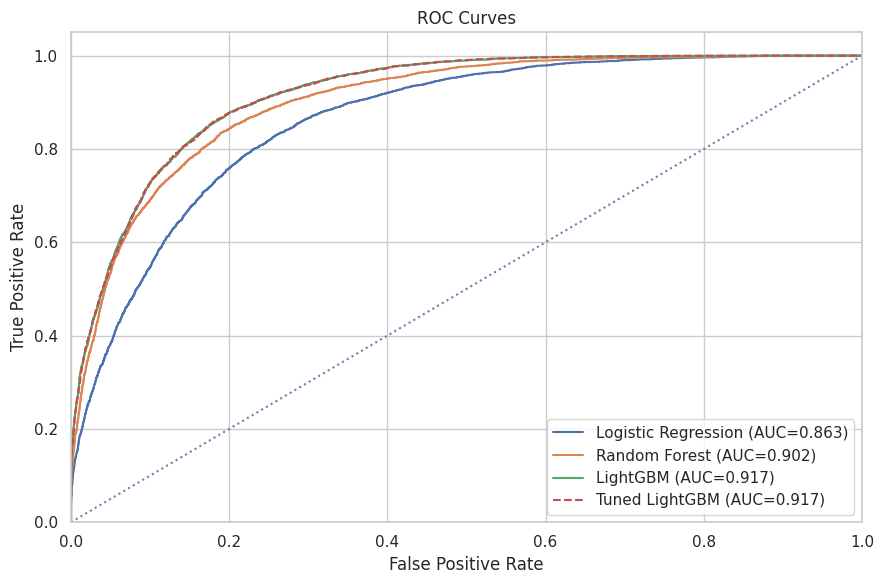

In [134]:
# ROC curves for all baseline models + tuned LightGBM
plt.figure(figsize=(9, 6))

for name in models:
    fpr, tpr, _ = roc_curve(y_test, probabilities[name])
    auc = roc_auc_score(y_test, probabilities[name])
    plt.plot(fpr, tpr, label=f'{name} (AUC={auc:.3f})')

fpr_tuned, tpr_tuned, _ = roc_curve(y_test, tuned_prob)
auc_tuned = roc_auc_score(y_test, tuned_prob)
plt.plot(fpr_tuned, tpr_tuned, linestyle='--', label=f'Tuned LightGBM (AUC={auc_tuned:.3f})')

plt.plot([0, 1], [0, 1], linestyle=':')
plt.xlim([0, 1])
plt.ylim([0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curves')
plt.legend(loc='lower right')
plt.tight_layout()
plt.show()

## Interpretation and Communication (2 marks)

Run the final cell below after training. It generates a concise, data-driven summary from the actual test results instead of hard-coding an AUC or claiming a model is best before comparing it.

In [135]:
# Final data-driven summary
final_comparison = pd.concat([results_df, tuned_results], ignore_index=True)
final_comparison = final_comparison.sort_values('ROC-AUC', ascending=False).reset_index(drop=True)

print('FINAL MODEL COMPARISON')
display(final_comparison.style.format({c: '{:.4f}' for c in final_comparison.columns[1:]}))

best_row = final_comparison.iloc[0]
print(f"\nHighest test ROC-AUC in this run: {best_row['Model']} ({best_row['ROC-AUC']:.4f})")
print(f"Accuracy: {best_row['Accuracy']:.4f}")
print(f"Precision: {best_row['Precision']:.4f}")
print(f"Recall: {best_row['Recall']:.4f}")
print(f"F1-score: {best_row['F1-Score']:.4f}")

print('\nInterpretation guidance:')
print('- Higher recall means fewer actual cancellations are missed.')
print('- Higher precision means fewer predicted cancellations are false alarms.')
print('- ROC-AUC measures ranking/discrimination across classification thresholds.')
print('- These metrics are from a held-out test set after removing post-booking leakage.')

FINAL MODEL COMPARISON


,Model,Accuracy,Precision,Recall,F1-Score,ROC-AUC
0,LightGBM,0.8503,0.7527,0.6793,0.7141,0.9174
1,Tuned LightGBM,0.8506,0.7522,0.6816,0.7152,0.9172
2,Random Forest,0.8301,0.8165,0.4938,0.6154,0.9020
3,Logistic Regression,0.8024,0.6842,0.5237,0.5933,0.8630



Highest test ROC-AUC in this run: LightGBM (0.9174)
Accuracy: 0.8503
Precision: 0.7527
Recall: 0.6793
F1-score: 0.7141

Interpretation guidance:
- Higher recall means fewer actual cancellations are missed.
- Higher precision means fewer predicted cancellations are false alarms.
- ROC-AUC measures ranking/discrimination across classification thresholds.
- These metrics are from a held-out test set after removing post-booking leakage.
